# MACHINE LEARNING FOR SURVIVAL ANALYSIS

## Imports and data loading

In [1]:
!pip install scikit-survival

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.3/298.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.4 MB/s eta 0:00:00
  Attempting uninstall: osqp
    Found existing installation: osqp 1.0.3
    Uninstalling osqp-1.0.3:
      Successfully uninstalled osqp-1.0.3


In [2]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 4.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=998bb4cf1bb921f3c8cf962830c0bf0df5e32472f7d9fca46dbe2c9c2dfc4adb
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


In [3]:
!pip install pycox torchtuples
!pip install torch torchvision torchaudio

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.3/141.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.7/413.7 kB 27.2 MB/s eta 0:00:00
  Created wheel for feather-format: filename=feather_format-0.4.1-py3-none-any.whl size=2434 sha256=3c103463b8a7d9c022399bacfcd06447215090731d310ddefd5af680aad61174
  Stored in directory: /root/.cache/pip/wheels/77/5b/0e/0e63d10b6353208a085a321ea2eed257

In [4]:
# Data manipulation
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning - Regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Model training & evaluation utilities
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, brier_score_loss
from sklearn.inspection import permutation_importance
from sklearn.utils import resample

# Survival Analysis - scikit-survival
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    integrated_brier_score,
    brier_score
)

# Survival Analysis - pycox and lifelines
import torch
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from torchtuples import optim
from lifelines.utils import concordance_index


In [5]:
using_colab = True
if using_colab:
  from google.colab import drive
  drive.mount('/content/drive/')

Mounted at /content/drive/


In [6]:
file_name='/content/drive/My Drive/MASTER/TFM_Ihona/ML/df_lung_cancer.csv'

In [7]:
df = pd.read_csv(file_name)
df.head()

,patient_id,NHC,sex,morphology,tobacco,age_group,time_to_event_days,time_to_event_months,time_to_event_years,death
0,3,11734238,1,Squamous,No,5,8,0.262834,0.021903,1
1,6,11943387,1,Squamous,No,4,265,8.706366,0.725530,1
2,8,12150847,2,Adenocarcinoma,No,4,829,27.236140,2.269678,1
3,12,12608694,1,Adenocarcinoma,No,4,152,4.993840,0.416153,1
4,22,13535175,1,Others,No,4,28,0.919918,0.076660,1


## Random Survival Forest

In [ ]:
file_name='/content/drive/My Drive/MASTER/TFM_Ihona/ML/df_lung_cancer.csv'
df = pd.read_csv(file_name)


In [ ]:
df.head()

,patient_id,NHC,sex,morphology,tobacco,age_group,time_to_event_days,time_to_event_months,time_to_event_years,death
0,3,11734238,1,Squamous,No,5,8,0.262834,0.021903,1
1,6,11943387,1,Squamous,No,4,265,8.706366,0.725530,1
2,8,12150847,2,Adenocarcinoma,No,4,829,27.236140,2.269678,1
3,12,12608694,1,Adenocarcinoma,No,4,152,4.993840,0.416153,1
4,22,13535175,1,Others,No,4,28,0.919918,0.076660,1


In [ ]:
df=df[["age_group", "morphology", "sex", "tobacco", "death", "time_to_event_months"]]

In [ ]:
# Create structured array for the target
y = Surv.from_dataframe("death", "time_to_event_months", df)

# Select features
X = df[["age_group", "morphology", "sex", "tobacco"]]

In [ ]:
# Initialize the encoder
encoder = OneHotEncoder(handle_unknown="ignore")
categorical_features = ["age_group", "morphology", "sex", "tobacco"]


# Fit and transform the training data
X_encoded = encoder.fit_transform(X[categorical_features])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [ ]:
# Step 0: Prepare structured y
# Make sure your y is in the correct dtype format for sksurv
y_structured = np.array(
    [(bool(e), float(t)) for e, t in zip(y["death"], y["time_to_event_months"])],
    dtype=[("death", "bool"), ("time_to_event_months", "float32")]
)

X = X_encoded  # features
y = y_structured  # structured target array

# 1. Scoring function for survival (concordance index)
def rsf_concordance_scorer(estimator, X, y):
    pred_surv = estimator.predict(X)
    event_ind = y['death']
    time = y['time_to_event_months']
    return concordance_index_censored(event_ind, time, pred_surv)[0]

# 2. Define parameter grid for RandomizedSearchCV
param_distributions = {
    "n_estimators": [50, 100, 150, 200],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 5, 10, 15, 20],
    "max_features": ["sqrt", "log2", 0.5, 0.75, 1.0],
}

# 3. Outer and inner cross-validation (5-fold)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Nested CV loop
outer_scores = []
best_params_list = []

for train_idx, test_idx in outer_cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    base_model = RandomSurvivalForest(n_jobs=-1, random_state=42)

    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=25,
        cv=inner_cv,
        scoring=rsf_concordance_scorer,
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(X_train, y_train)

    best_params_list.append(random_search.best_params_)
    best_model = random_search.best_estimator_
    test_score = rsf_concordance_scorer(best_model, X_test, y_test)
    outer_scores.append(test_score)

# 5. Print final CV result
mean_cidx = np.mean(outer_scores)
std_cidx = np.std(outer_scores)
print(f"Average C-index (RSF) from Outer CV: {mean_cidx:.3f} ± {std_cidx:.3f}")

# 6. Get the best hyperparameters (from best outer fold)
best_idx = np.argmax(outer_scores)
final_best_params = best_params_list[best_idx]
print("Best hyperparameters from best performing fold:")
print(final_best_params)

# 7. Train final model on full dataset
final_rsf_model = RandomSurvivalForest(**final_best_params, n_jobs=-1, random_state=42)

Average C-index (RSF) from Outer CV: 0.622 ± 0.016
Best hyperparameters from best performing fold:
{'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 15, 'max_features': 'sqrt'}


In [ ]:
final_rsf_model.fit(X, y)

RandomSurvivalForest(min_samples_leaf=15, min_samples_split=10, n_estimators=50,
                     n_jobs=-1, random_state=42)

In [ ]:
# Convert sparse matrix to dense array
X_encoded_dense = X_encoded.toarray()

# Get the feature names from the encoder
feature_names = encoder.get_feature_names_out(categorical_features)


In [ ]:

X_df = pd.DataFrame(X_encoded_dense, columns=feature_names)


In [ ]:
perm_result = permutation_importance(
    estimator=final_rsf_model,
    X=X_df.values,
    y=y,  # structured survival array
    scoring=rsf_concordance_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


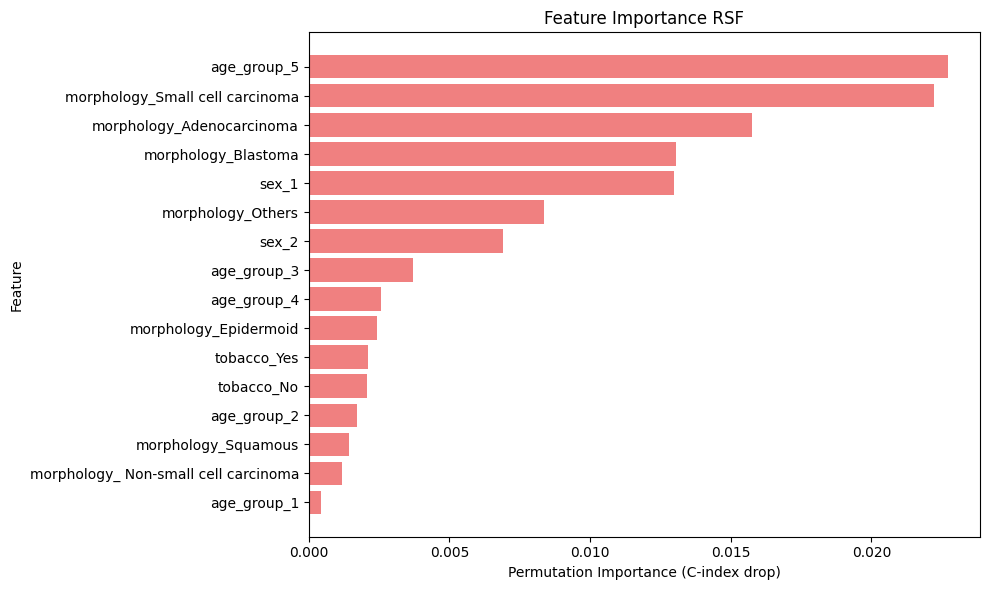

In [ ]:
sorted_idx = np.argsort(perm_result.importances_mean)

plt.figure(figsize=(10, 6))
plt.barh(
    y=np.array(feature_names)[sorted_idx],
    width=perm_result.importances_mean[sorted_idx],
    # xerr=perm_result.importances_std[sorted_idx],
    color="lightcoral",
    # edgecolor="black"
)
plt.xlabel("Permutation Importance (C-index drop)")
plt.ylabel("Feature")
plt.title("Feature Importance RSF")
plt.tight_layout()
plt.show()


In [ ]:
# Decide the time grid

# y is the structured survival array
times = y["time_to_event_months"]
print(f"Min: {np.min(times)} | 90th percentile: {np.percentile(times, 90)} | Max: {np.max(times)}")


Min: 0.03285421058535576 | 90th percentile: 70.66940307617188 | Max: 119.81930541992188


In [ ]:
time_grid = np.arange(1, 71)  # 1 to 70 months

#Covers up to the 90th percentile
#Avoids the tail with high censoring, making the IBS more stable and fair

In [ ]:
n_bootstrap = 100
ibs_scores = []

for i in range(n_bootstrap):
    train_idx = resample(np.arange(X.shape[0]), replace=True)
    test_idx = np.setdiff1d(np.arange(X.shape[0]), train_idx)

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = final_rsf_model.fit(X_train, y_train)
    surv_funcs = model.predict_survival_function(X_test)
    pred_surv = np.array([[fn(t) for t in time_grid] for fn in surv_funcs])

    ibs = integrated_brier_score(y_train, y_test, pred_surv, time_grid)
    ibs_scores.append(ibs)

print(f"Bootstrapped IBS (like Boot632): {np.mean(ibs_scores):.3f} ± {np.std(ibs_scores):.3f}")



Bootstrapped IBS (like Boot632): 0.199 ± 0.007


## Gradient boosting

In [ ]:
y_structured = np.array(
    [(bool(e), float(t)) for e, t in zip(y["death"], y["time_to_event_months"])],
    dtype=[("death", "bool"), ("time_to_event_months", "float32")]
)

X = X_encoded  # features
y = y_structured  # structured target array

outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

outer_scores = []
best_params_list = []

def gbsa_concordance_scorer(estimator, X, y):
    pred_surv = estimator.predict(X)
    return concordance_index_censored(y['death'], y['time_to_event_months'], pred_surv)[0]

param_distributions = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10],
    "subsample": [0.6, 0.8, 1.0],
}


for train_idx, test_idx in outer_cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    base_model = GradientBoostingSurvivalAnalysis(random_state=42)

    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=25,
        cv=inner_cv,
        scoring=gbsa_concordance_scorer,
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(X_train, y_train)
    best_params_list.append(random_search.best_params_)
    best_gbsa_model = random_search.best_estimator_
    test_score = gbsa_concordance_scorer(best_gbsa_model, X_test, y_test)
    outer_scores.append(test_score)

print(f"Average C-index (GBSA) from Outer CV: {np.mean(outer_scores):.3f} ± {np.std(outer_scores):.3f}")

best_idx = np.argmax(outer_scores)
final_best_params = best_params_list[best_idx]
print("Best hyperparameters from best performing fold:")
print(final_best_params)

# Train final model on full dataset
final_gbsa_model = GradientBoostingSurvivalAnalysis(**final_best_params, random_state=42)

Average C-index (GBSA) from Outer CV: 0.620 ± 0.014
Best hyperparameters from best performing fold:
{'subsample': 0.8, 'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 2, 'learning_rate': 0.1}


In [ ]:
final_gbsa_model.fit(X, y)

GradientBoostingSurvivalAnalysis(max_depth=2, min_samples_leaf=5,
                                 min_samples_split=10, n_estimators=150,
                                 random_state=42, subsample=0.8)

In [ ]:
perm_result = permutation_importance(
    estimator=final_gbsa_model,
    X=X_df.values,
    y=y,  # structured survival array
    scoring=gbsa_concordance_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

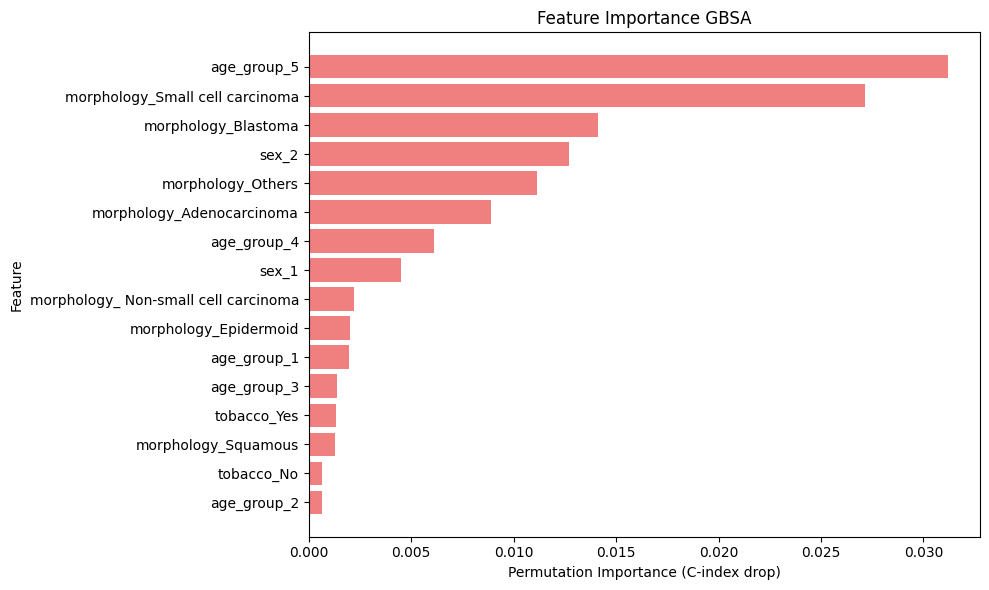

In [ ]:

sorted_idx = np.argsort(perm_result.importances_mean)

plt.figure(figsize=(10, 6))
plt.barh(
    y=np.array(feature_names)[sorted_idx],
    width=perm_result.importances_mean[sorted_idx],
    # xerr=perm_result.importances_std[sorted_idx],
    color="lightcoral",
    # edgecolor="black"
)
plt.xlabel("Permutation Importance (C-index drop)")
plt.ylabel("Feature")
plt.title("Feature Importance GBSA")
plt.tight_layout()
plt.show()


In [ ]:
n_bootstrap = 100
ibs_scores = []

for i in range(n_bootstrap):
    train_idx = resample(np.arange(X.shape[0]), replace=True)
    test_idx = np.setdiff1d(np.arange(X.shape[0]), train_idx)

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = final_gbsa_model.fit(X_train, y_train)
    surv_funcs = model.predict_survival_function(X_test)
    pred_surv = np.array([[fn(t) for t in time_grid] for fn in surv_funcs])

    ibs_gbsa = integrated_brier_score(y_train, y_test, pred_surv, time_grid)
    ibs_scores.append(ibs_gbsa)

print(f"Bootstrapped IBS (like Boot632): {np.mean(ibs_scores):.3f} ± {np.std(ibs_scores):.3f}")

Bootstrapped IBS (like Boot632): 0.198 ± 0.007


# DEEP SURV

In [9]:
# Load dataset
df = pd.read_csv(file_name)

# Separate features and survival labels
X = df.drop(columns=["time_to_event_days", "time_to_event_months", "time_to_event_years", "death"])
time = df["time_to_event_months"]  # Survival time
event = df["death"]  # Censoring indicator (1=death, 0=censored)

# Encode categorical variables
categorical_cols = ["sex", "morphology", "tobacco", "age_group"]  # Adjust based on dataset

label_encoder = LabelEncoder()

# Apply Label Encoding for ordinal variables (if any)
X["age_group"] = label_encoder.fit_transform(X["age_group"])

# One-Hot Encode nominal variables
X = pd.get_dummies(X, columns=["sex", "morphology", "tobacco"], drop_first=True)

# Standardize numerical variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, time, test_size=0.2, random_state=42)
event_train, event_test = train_test_split(event, test_size=0.2, random_state=42)

# Convert to numpy arrays for DeepSurv
X_train, X_test = X_train.values, X_test.values
y_train, y_test = y_train.values, y_test.values
event_train, event_test = event_train.values, event_test.values


In [ ]:
X = X_scaled.values.astype(np.float32)
y = df["time_to_event_months"].values.astype(np.float32)
event = df["death"].values.astype(np.float32)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cindex_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    event_train, event_test = event[train_idx], event[test_idx]

    # Convert to torch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    event_train_tensor = torch.tensor(event_train, dtype=torch.float32)

    # Define network
    in_features = X.shape[1]
    net = torch.nn.Sequential(
        torch.nn.Linear(in_features, 32),
        torch.nn.ReLU(),
        torch.nn.BatchNorm1d(32),
        torch.nn.Linear(32, 32),
        torch.nn.ReLU(),
        torch.nn.BatchNorm1d(32),
        torch.nn.Linear(32, 1)
    )

    model = CoxPH(net, optim.Adam)
    model.fit(X_train_tensor, (y_train_tensor, event_train_tensor), batch_size=256, epochs=100, verbose=False)

    # Predict risk scores on test set
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    risk_scores = model.predict(X_test_tensor)

    # Compute C-index
    cidx = concordance_index(y_test, -risk_scores, event_test)
    cindex_scores.append(cidx)

# Final result
print(f"Cross-validated C-index (DeepSurv): {np.mean(cindex_scores):.3f} ± {np.std(cindex_scores):.3f}")


Cross-validated C-index (DeepSurv): 0.603 ± 0.012


In [ ]:
# Make sure the arrays are numpy format
X = X_scaled.values.astype(np.float32)
y = df["time_to_event_months"].values.astype(np.float32)
event = df["death"].values.astype(np.float32)

n_bootstrap = 100
ibs_scores = []

# Time grid
time_grid = np.arange(1, 71)

for i in range(n_bootstrap):
    # Bootstrap sampling
    train_idx = resample(np.arange(X.shape[0]), replace=True, random_state=i)
    test_idx = np.setdiff1d(np.arange(X.shape[0]), train_idx)

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    e_train, e_test = event[train_idx], event[test_idx]

    # Train DeepSurv on bootstrap sample
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    e_train_tensor = torch.tensor(e_train, dtype=torch.float32)

    in_features = X.shape[1]
    net = torch.nn.Sequential(
        torch.nn.Linear(in_features, 32),
        torch.nn.ReLU(),
        torch.nn.BatchNorm1d(32),
        torch.nn.Linear(32, 32),
        torch.nn.ReLU(),
        torch.nn.BatchNorm1d(32),
        torch.nn.Linear(32, 1)
    )

    model = CoxPH(net, optim.Adam)
    model.fit(X_train_tensor, (y_train_tensor, e_train_tensor), batch_size=256, epochs=100, verbose=False)
    model.compute_baseline_hazards()

    # Predict survival functions for test set
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    surv = model.predict_surv_df(X_test_tensor)

    # Evaluate Brier score
    ev = EvalSurv(surv, y_test, e_test, censor_surv='km')
    brier_scores = ev.brier_score(time_grid)
    ibs = np.trapezoid(brier_scores, time_grid) / (time_grid[-1] - time_grid[0])
    ibs_scores.append(ibs)

# Final result
print(f"Bootstrapped IBS (DeepSurv): {np.mean(ibs_scores):.3f} ± {np.std(ibs_scores):.3f}")


Bootstrapped IBS (DeepSurv): 0.226 ± 0.009
